# Amharic NLP Correction: Synthetic OCR Error Experiments

This notebook develops the first version of the NLP post-processing component for the handwritten Amharic OCR project. It is designed to work before the CRNN+CTC/TrOCR recognition model is available by using synthetic OCR errors.

**Research role:** NLP correction, evaluation, and error analysis.

**Pipeline:** clean/reference text → synthetic OCR error → dictionary-based correction → before/after CER/WER.

The final proposal specifies an NLP-based post-processing correction module using Amharic-specific language patterns, with dictionary-based edit-distance correction explicitly listed as a feasible approach.


In [3]:
from pathlib import Path
import re
import random
import unicodedata
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

import pandas as pd

random.seed(42)

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "results"
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

plt.rcParams["font.family"] = "Noto Sans Ethiopic"

WORDLIST_PATH = DATA_DIR / "amharic_wordlist.txt"
print(ROOT)

/Users/eyobnebyou/Desktop/amharic-handwritten-ocr/nlp_correction/notebooks


In [5]:
%pip install requests

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.font_manager as fm

fm.fontManager.addfont("/Users/eyobnebyou/Library/Fonts/NotoSansEthiopic[wdth,wght].ttf")

print([f.name for f in fm.fontManager.ttflist if "Ethiopic" in f.name])

['Noto Sans Ethiopic']


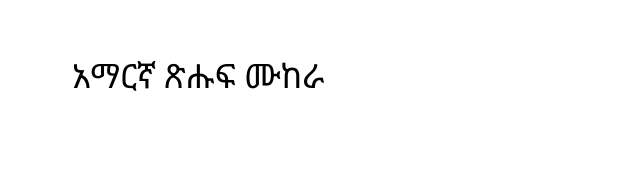

In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Noto Sans Ethiopic"

plt.figure(figsize=(8, 2))
plt.text(0.1, 0.5, "አማርኛ ጽሑፍ ሙከራ", fontsize=24)
plt.axis("off")
plt.show()

## 1. Amharic wordlist

For the first experiment we use the **Wikidict Amharic wordlist**, which is derived from Wikipedia article titles and contains about 11,014 Amharic entries according to the repository documentation. It is released under CC0 according to that repository.

This is useful as an initial open lexical resource, but it is not a complete Amharic vocabulary. In particular, handwritten text may contain inflected forms, names, numbers, abbreviations, and words absent from a dictionary. Therefore, a dictionary-only corrector must be conservative and will be treated as a baseline rather than the final NLP method.


In [13]:
import requests

WORDLIST_URL = "https://raw.githubusercontent.com/open-dict-data/wikidict-wordlist/master/data/am-wordlist_wiki.txt"

if not WORDLIST_PATH.exists():
    response = requests.get(WORDLIST_URL)
    response.raise_for_status()
    WORDLIST_PATH.write_bytes(response.content)



print(f"Saved: {WORDLIST_PATH}")


Saved: /Users/eyobnebyou/Desktop/amharic-handwritten-ocr/nlp_correction/notebooks/data/amharic_wordlist.txt


In [18]:
with open(WORDLIST_PATH, "r", encoding="utf-8") as f:
    words = [line.strip() for line in f if line.strip()]

print(f"Number of words: {len(words)}")
print(words[:20])

Number of words: 11017
['አፍሪቃ', 'ጃፓን', 'ደቡብ አሜሪካ', 'ኖርዌይ', 'ኢንግላንድ', 'ስኮትላንድ', 'ዌልስ', 'ስሜን አየርላንድ', 'አየርላንድ ሪፐብሊክ', 'ሀንጋሪ', 'እስፓንያ', 'አሜሪካ', 'ቤልጅግ', 'ሉክሰምበርግ', 'መሬት', 'ህይወት', 'የሰው ልጅ', 'ጆርጅ ዋሽንግተን', 'ፊንላንድ', 'ስዊድን']


In [11]:
def normalize_unicode(text):
    return unicodedata.normalize("NFC", text.strip())

def load_wordlist(path):
    words = set()

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = normalize_unicode(line)
            tokens = re.findall(r"[\u1200-\u137F]+", line)

            for token in tokens:
                words.add(token)

    return sorted(words)

wordlist = load_wordlist(WORDLIST_PATH)
word_set = set(wordlist)

print("Number of Amharic words:", len(wordlist))
print("Examples:", wordlist[:20])

Number of Amharic words: 11235
Examples: ['ሀ', 'ሀሌ', 'ሀመር', 'ሀሙስ', 'ሀማርቢ', 'ሀማሴን', 'ሀሜት', 'ሀሜትና', 'ሀምሌና', 'ሀምሳ', 'ሀረርጌ', 'ሀረጉን', 'ሀረግ', 'ሀሩ', 'ሀሪሰን', 'ሀሪንግተን', 'ሀራሪ', 'ሀራሬ', 'ሀሮ', 'ሀሰተኛ']


### Optional second lexical resource

The Ge'ez Frontier Foundation also publishes Amharic lexical data, including several dictionary collections. We can add one of these later and compare correction coverage.

For now, we keep one wordlist as the controlled baseline so that we can measure exactly what changes when the lexical resource changes.


## 2. Ethiopic visual-confusion candidates

These mappings are an **initial manually defined hypothesis**, not a claim that every pair is a real OCR confusion. We will later replace/refine them using confusion statistics from the actual HTR model.

The key research step will eventually be: real OCR predictions → character confusion matrix → empirically supported confusion pairs → synthetic error generator.

In [20]:
FIDEL_FAMILIES = {
    "ዘ": ["ዘ", "ዙ", "ዚ", "ዛ", "ዜ", "ዝ", "ዞ"],
    "ዠ": ["ዠ", "ዡ", "ዢ", "ዣ", "ዤ", "ዥ", "ዦ"],
    "ሰ": ["ሰ", "ሱ", "ሲ", "ሳ", "ሴ", "ስ", "ሶ"],
    "ሸ": ["ሸ", "ሹ", "ሺ", "ሻ", "ሼ", "ሽ", "ሾ"],
    "በ": ["በ", "ቡ", "ቢ", "ባ", "ቤ", "ብ", "ቦ"],
    "ቨ": ["ቨ", "ቩ", "ቪ", "ቫ", "ቬ", "ቭ", "ቮ"],
    "ተ": ["ተ", "ቱ", "ቲ", "ታ", "ቴ", "ት", "ቶ"],
    "ቸ": ["ቸ", "ቹ", "ቺ", "ቻ", "ቼ", "ች", "ቾ"],
    "ነ": ["ነ", "ኑ", "ኒ", "ና", "ኔ", "ን", "ኖ"],
    "ኀ": ["ኀ", "ኁ", "ኂ", "ኃ", "ኄ", "ኅ", "ኆ"],
    "አ": ["አ", "ኡ", "ኢ", "ኣ", "ኤ", "እ", "ኦ"],
    "ከ": ["ከ", "ኩ", "ኪ", "ካ", "ኬ", "ክ", "ኮ"],
    "ኸ": ["ኸ", "ኹ", "ኺ", "ኻ", "ኼ", "ኽ", "ኾ"],
    "ወ": ["ወ", "ዉ", "ዊ", "ዋ", "ዌ", "ው", "ዎ"],
    "ዐ": ["ዐ", "ዑ", "ዒ", "ዓ", "ዔ", "ዕ", "ዖ"],
    "ደ": ["ደ", "ዱ", "ዲ", "ዳ", "ዴ", "ድ", "ዶ"],
    "ጀ": ["ጀ", "ጁ", "ጂ", "ጃ", "ጄ", "ጅ", "ጆ"],
    "ጸ": ["ጸ", "ጹ", "ጺ", "ጻ", "ጼ", "ጽ", "ጾ"],
    "ጰ": ["ጰ", "ጱ", "ጲ", "ጳ", "ጴ", "ጵ", "ጶ"]
}

CONFUSION_FAMILIES = [
    ("ዘ", "ዠ"),
    ("ሰ", "ሸ"),
    ("በ", "ቨ"),
    ("ተ", "ቸ"),
    ("ነ", "ኀ"),
    ("አ", "ከ"),
    ("አ", "ኸ"),
    ("ከ", "ኸ"),
    ("ወ", "ዐ"),
    ("ደ", "ጀ"),
    ("ደ", "ጸ"),
    ("ጸ", "ጰ")
]

print("Fidel families:", len(FIDEL_FAMILIES))
print("Confusion relationships:", len(CONFUSION_FAMILIES))

Fidel families: 19
Confusion relationships: 12


## 3. Synthetic OCR Error Generator

The generator simulates four types of OCR errors considered in the research proposal:

* **visually confusable Ethiopic characters** based on expert-informed hypotheses about handwritten Fidel forms
* **character deletion**
* **character insertion**
* **spacing and word-boundary errors**

Each transformation is applied probabilistically, allowing us to generate multiple corrupted versions of the same clean text. This provides controlled noisy OCR-like input for developing and evaluating the NLP correction module before the actual OCR model is available.


In [24]:
def corrupt_visual(word, probability=0.25):
    out = []
    for ch in word:
        if ch in VISUAL_CONFUSIONS and random.random() < probability:
            out.append(random.choice(VISUAL_CONFUSIONS[ch]))
        else:
            out.append(ch)
    return "".join(out)

def corrupt_deletion(word, probability=0.08):
    if len(word) <= 2:
        return word
    return "".join(ch for ch in word if random.random() >= probability)

def corrupt_insertion(word, probability=0.05):
    if not word:
        return word
    chars = list(word)
    out = []
    for ch in chars:
        out.append(ch)
        if random.random() < probability:
            out.append(random.choice(chars))
    return "".join(out)

def corrupt_spacing(text, probability=0.15):
    words = text.split()
    if len(words) < 2:
        return text
    out = []
    i = 0
    while i < len(words):
        if i < len(words) - 1 and random.random() < probability:
            out.append(words[i] + words[i + 1])
            i += 2
        else:
            out.append(words[i])
            i += 1
    return " ".join(out)

def corrupt_text(text, visual_p=0.25, deletion_p=0.08, insertion_p=0.05, spacing_p=0.15):
    words = text.split()
    corrupted_words = []
    for word in words:
        word = corrupt_visual(word, visual_p)
        word = corrupt_deletion(word, deletion_p)
        word = corrupt_insertion(word, insertion_p)
        if word:
            corrupted_words.append(word)
    corrupted = " ".join(corrupted_words)
    return corrupt_spacing(corrupted, spacing_p)

print("Synthetic OCR error generator ready.")

Synthetic OCR error generator ready.


## 4. Try the synthetic generator

Use clean Amharic sentences as the reference. For this early development stage, manually supplied sentences are fine. Later we should sample reference text from the Fidel transcriptions so that the synthetic experiments match the project's actual domain.

In [25]:
examples = [
    "ይህ የአማርኛ ጽሑፍ ነው",
    "ተማሪው መጽሐፉን አነበበ",
    "ኢትዮጵያ በአፍሪካ ቀንድ ትገኛለች",
]

for text in examples:
    corrupted = corrupt_text(text)
    print("REFERENCE :", text)
    print("CORRUPTED :", corrupted)
    print()

REFERENCE : ይህ የአማርኛ ጽሑፍ ነው
CORRUPTED : ይህህ የዐማዐር ጽሑፍኑው

REFERENCE : ተማሪው መጽሐፉን አነበበ
CORRUPTED : ቸማሪው መሐፉ አነቡ

REFERENCE : ኢትዮጵያ በአፍሪካ ቀንድ ትገኛለች
CORRUPTED : ኢትዮጵ በአፍሪካቀንድ ትገኛለች



## 5. Edit distance

For the first correction baseline, we use character-level Levenshtein distance. The corrector searches the wordlist for the closest candidate.

Important: a pure nearest-word lookup can produce harmful corrections. We therefore introduce a **maximum distance threshold** and leave a word unchanged when no sufficiently close candidate exists.

In [26]:
def levenshtein(a, b):
    if a == b:
        return 0
    if not a:
        return len(b)
    if not b:
        return len(a)

    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, start=1):
        current = [i]
        for j, cb in enumerate(b, start=1):
            insertion = current[j - 1] + 1
            deletion = previous[j] + 1
            substitution = previous[j - 1] + (ca != cb)
            current.append(min(insertion, deletion, substitution))
        previous = current
    return previous[-1]

def closest_words(word, candidates, max_distance=2):
    best_distance = max_distance + 1
    best = []
    for candidate in candidates:
        distance = levenshtein(word, candidate)
        if distance < best_distance:
            best_distance = distance
            best = [candidate]
        elif distance == best_distance:
            best.append(candidate)
    return best, best_distance

    

In [27]:
test_word = "ቸማሪ"

best, distance = closest_words(test_word, wordlist, max_distance=2)

print("OCR word:", test_word)
print("Closest words:", best[:10])
print("Distance:", distance)

OCR word: ቸማሪ
Closest words: ['ማሪ', 'የማሪ', 'ጭማሪ']
Distance: 1


In [34]:
def closest_words(word, candidates, max_distance=2, length_tolerance=2):
    best_distance = max_distance + 1
    best = []

    for candidate in candidates:
        if abs(len(word) - len(candidate)) > length_tolerance:
            continue

        distance = levenshtein(word, candidate)

        if distance < best_distance:
            best_distance = distance
            best = [candidate]
        elif distance == best_distance:
            best.append(candidate)

    return best, best_distance


def correct_word(word, candidates, max_distance=2, length_tolerance=2):
    best, distance = closest_words(
        word,
        candidates,
        max_distance=max_distance,
        length_tolerance=length_tolerance
    )

    if distance <= max_distance and best:
        return best[0]

    return word

In [36]:
test_words = ["መሐፉ", "ኢትዮጵ", "አማዐር"]

for word in test_words:
    corrected = correct_word(word, wordlist, max_distance=2)
    print(word, "->", corrected)

መሐፉ -> መሐላ
ኢትዮጵ -> ኢትዮ
አማዐር -> አማር


In [37]:
for word in ["መሐፉ", "ኢትዮጵ", "አማዐር"]:
    best, distance = closest_words(word, wordlist, max_distance=2)

    print("OCR:", word)
    print("Distance:", distance)
    print("Candidates:", best[:10])
    print()

OCR: መሐፉ
Distance: 1
Candidates: ['መሐላ']

OCR: ኢትዮጵ
Distance: 1
Candidates: ['ኢትዮ', 'ኢትዮጵያ']

OCR: አማዐር
Distance: 1
Candidates: ['አማር']



### Speed improvement

The simple implementation above is intentionally clear, but scanning 11,000+ words for every token will become expensive. The next version will restrict candidates by word length and use a faster search/index. For this first notebook, we can already make a length-bucketed candidate index.

In [39]:
words_by_length = defaultdict(list)

for word in wordlist:
    words_by_length[len(word)].append(word)


def correct_word(word, max_distance=2, length_window=2):
    word = normalize_unicode(word)

    if not word or word in word_set or not is_amharic_word(word):
        return word, 0, word

    candidates = []

    min_len = max(1, len(word) - length_window)
    max_len = len(word) + length_window

    for length in range(min_len, max_len + 1):
        candidates.extend(words_by_length.get(length, []))

    best, distance = closest_words(
        word,
        candidates,
        max_distance=max_distance
    )

    if distance > max_distance or not best:
        return word, distance, word

    chosen = sorted(best)[0]

    return word, distance, chosen

In [40]:
tests = ["ሀገር", "ሀጋር", "ሆድ", "ሆድድ"]

for word in tests:
    print(correct_word(word))

('ሀገር', 0, 'ሀገር')
('ሀጋር', 1, 'ሀመር')
('ሆድ', 0, 'ሆድ')
('ሆድድ', 1, 'ሆድ')


## 6. Sentence-level correction

The first version corrects each token independently. This is deliberately simple. It gives us a measurable baseline before we introduce contextual NLP.

Later, if the dictionary baseline is useful but limited, we can test a language-model or contextual scoring stage to choose between multiple candidate corrections.

In [ ]:
def correct_text(text, max_distance=2, length_window=2):
    tokens = text.split()
    corrected = []
    changes = []

    for token in tokens:
        original, distance, replacement = correct_word(
            token,
            max_distance=max_distance,
            length_window=length_window,
        )
        corrected.append(replacement)
        if original != replacement:
            changes.append({
                "original": original,
                "replacement": replacement,
                "distance": distance,
            })

    return " ".join(corrected), changes

for text in examples:
    corrupted = corrupt_text(text)
    corrected, changes = correct_text(corrupted)
    print("REFERENCE :", text)
    print("OCR       :", corrupted)
    print("CORRECTED :", corrected)
    print("CHANGES   :", changes)
    print()

## 7. CER and WER evaluation

The proposal explicitly identifies CER and WER as the recognition/correction evaluation measures. fileciteturn0file0L78-L86

For correction experiments we need three measurements:

1. reference vs synthetic OCR output
2. reference vs corrected output
3. whether the correction actually helped or harmed each sample

In [ ]:
def cer(reference, hypothesis):
    reference = reference.replace(" ", "")
    hypothesis = hypothesis.replace(" ", "")
    if not reference:
        return 0.0 if not hypothesis else 1.0
    return levenshtein(reference, hypothesis) / len(reference)

def wer(reference, hypothesis):
    ref_words = reference.split()
    hyp_words = hypothesis.split()
    
    if not ref_words:
        return 0.0 if not hyp_words else 1.0

    previous = list(range(len(hyp_words) + 1))
    for i, ref_word in enumerate(ref_words, start=1):
        current = [i]
        for j, hyp_word in enumerate(hyp_words, start=1):
            current.append(min(
                current[j - 1] + 1,
                previous[j] + 1,
                previous[j - 1] + (ref_word != hyp_word),
            ))
        previous = current
    return previous[-1] / len(ref_words)

def evaluate_pair(reference, hypothesis):
    return {
        "CER": cer(reference, hypothesis),
        "WER": wer(reference, hypothesis),
    }

In [ ]:
rows = []

for reference in examples:
    ocr_output = corrupt_text(reference)
    corrected, changes = correct_text(ocr_output)

    before = evaluate_pair(reference, ocr_output)
    after = evaluate_pair(reference, corrected)

    rows.append({
        "reference": reference,
        "ocr_output": ocr_output,
        "corrected_output": corrected,
        "CER_before": before["CER"],
        "CER_after": after["CER"],
        "WER_before": before["WER"],
        "WER_after": after["WER"],
        "changed_tokens": len(changes),
    })

results_df = pd.DataFrame(rows)
results_df

## 8. First summary

For the synthetic experiment, compare the mean CER/WER before and after correction. Later, when real OCR output is available, the same table will be generated from Fidel test-set predictions.

In [ ]:
summary = pd.DataFrame({
    "metric": ["CER", "WER"],
    "before": [results_df["CER_before"].mean(), results_df["WER_before"].mean()],
    "after": [results_df["CER_after"].mean(), results_df["WER_after"].mean()],
})

summary["absolute_change"] = summary["after"] - summary["before"]
summary["relative_change_percent"] = ((summary["after"] - summary["before"]) / summary["before"]) * 100
summary

## 9. What we should NOT conclude yet

A lower synthetic CER/WER does **not** establish that the final OCR system is improved. The synthetic generator currently contains assumptions about which characters are confused and how errors occur.

The real research experiment begins when the HTR model produces predictions on the held-out Fidel test set. Then we will:

1. measure real baseline CER/WER;
2. build an empirical character confusion table;
3. classify real errors;
4. run the correction module on those predictions;
5. compare before/after CER and WER on exactly the same test samples;
6. inspect both successful and harmful corrections.

## 10. Next development steps

- Replace the manually typed examples with Fidel transcription samples.
- Improve tokenization and punctuation handling.
- Add a frequency-aware candidate ranking instead of alphabetical tie-breaking.
- Add a real Ethiopic confusion matrix once HTR predictions exist.
- Test different maximum edit distances.
- Measure correction precision: when the module changes a word, how often is the change actually correct?
- Add contextual scoring so that a candidate is judged using surrounding words rather than edit distance alone.
- Keep the synthetic experiment separate from the final real-OCR evaluation.

This progression follows the proposal's requirement to develop an NLP post-processing module and evaluate it rather than assuming that correction will eliminate recognition errors. fileciteturn0file0L112-L122